# Lab10 - Unsupervised Learning

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

The topic of this lab is unsupervised learning. We will use historical data from one of the assignment tasks from previous years - https://knowledgepit.ml/iml2022project2.

The samples in the dataset were collected during training sessions of firefighters. They were equipped with various sensors attached to their bodies to monitor their physical condition as well as their movements. The goal of this lab is to explore the dataset and apply unsupervised learning techniques to cluster the activities performed by the firefighters. We will use clustering algorithms to group similar activities together, visualize the results, and evaluate the clustering performance.

An example of the exercise performed by the firefighters can be seen in the following video:
https://youtu.be/i6skdm1UoWM


In this lab, you will explore how to:

* Navigate the "Curse of Dimensionality": Understand why high-dimensional data makes distance-based patterns harder to find.
* Apply Clustering Algorithms: Use techniques like K-Means, DBSCAN, and HDBSCAN to group similar activities together automatically.
* Visualize High-Dimensional Space: Use UMAP to flatten complex sensor signals into 2D maps to see if the machine can "discover" the different stages of a rescue operation.
* Evaluate Performance: Implement and calculate the Silhouette score to mathematically determine how well-defined your discovered clusters are.

You will not be told what activity each row corresponds to - your job is to recover that structure from the geometry of the data alone. Along the way you'll bump into the three central practical questions of clustering: (1) which algorithm fits the shape of my data? (k-means assumes round blobs; DBSCAN finds density blobs of arbitrary shape; HDBSCAN finds them at multiple scales), (2) how do I evaluate clusters without ground-truth labels? (silhouette and friends), and (3) what do I do when the feature space has dozens of dimensions and my distance metric stops being informative? (the curse of dimensionality, and how UMAP/PCA mitigate it).

Our objective is to see if these algorithms can successfully organize the raw data into meaningful groups that correspond to the physical activities performed in the field.
By the end you should be able to:
* take an unfamiliar dataset, decide on a sensible preprocessing pipeline, and apply at least four clustering algorithms; 
* measure their quality with silhouette score (including your own from-scratch implementation, to be sure you understand it);
* compare algorithms on the speed-vs-quality axis, because in production you almost always have both constraints.

## 0. Import libraries

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# and others, as you see fit


## 1. Data preparation

Always consider using some form of scaling. Clustering is purely based on distance; if 'Heart Rate' is 60–180 and 'G-Force' is 0–1, the algorithm will treat a change of 1 pulse as being as significant as the entire range of motion.

When using UMAP for visualization, set a random_state to ensure your plots look the same every time you run the cell.

In [147]:
X = pd.read_csv("Lab10_data_pool.csv")
X


,ll_acc_x_mean1,ll_acc_x_mean2,ll_acc_x_mean3,ll_acc_x_mean4,ll_acc_x_mean5,ll_acc_x_sd1,ll_acc_x_sd2,ll_acc_x_sd3,ll_acc_x_sd4,ll_acc_x_sd5,...,torso_acc_length_median1,torso_acc_length_median2,torso_acc_length_median3,torso_acc_length_median4,torso_acc_length_median5,torso_gyro_length_median1,torso_gyro_length_median2,torso_gyro_length_median3,torso_gyro_length_median4,torso_gyro_length_median5
0,-9.7759,-8.8555,-8.2527,-7.6126,-7.0833,0.3691,2.0333,1.0984,0.3497,1.4128,...,9.9530,11.3088,11.9601,11.0521,10.0823,85.7797,99.7707,65.6239,39.4626,30.8416
1,-9.5503,-8.2558,-9.4273,-9.7671,-12.3221,10.6996,0.8829,2.1807,5.4049,9.1767,...,13.8216,12.7748,12.2519,9.2821,9.7583,116.6986,53.8955,123.0335,109.8054,127.3275
2,-15.3899,-11.1862,-16.8448,-10.2907,-17.3281,5.6965,16.4654,6.4076,17.9919,9.9795,...,11.5928,16.2866,10.7796,13.2520,11.3925,65.9531,78.9421,61.4511,64.4757,91.7237
3,-9.3191,-10.5277,-9.3329,-9.7442,-9.7748,1.6281,1.4145,4.1604,0.2180,0.2170,...,11.0323,10.1001,10.9959,10.2174,11.1232,32.1007,98.0114,75.4095,58.1739,38.3745
4,-10.1414,-14.6758,-10.9610,-12.1265,-12.4981,15.6653,15.5570,21.8813,9.1379,21.5038,...,10.9251,12.1174,14.2899,15.0440,14.0081,96.0986,79.1336,108.5430,80.5364,106.3759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-8.7163,-8.6049,-7.4090,-8.9152,-8.8888,2.7392,1.2924,2.3494,3.6094,1.4203,...,13.0317,11.0924,10.3284,12.9893,12.4520,135.5655,53.0561,136.1166,127.3345,69.3787
19996,-10.6644,-7.4859,-9.7861,-9.5074,-9.6588,3.7335,3.9397,6.3871,1.3448,0.2967,...,10.6707,9.1483,14.0784,11.1902,10.8463,47.6475,156.0265,137.5738,24.0866,33.3158
19997,-17.4385,-10.4626,-20.2318,-8.9492,-20.1127,14.7990,11.3458,16.2817,9.9342,20.1696,...,12.2569,9.4723,9.0098,9.3487,7.9370,103.8819,103.6438,116.3426,117.7207,85.5008
19998,-1.5759,-1.7234,-1.8101,-1.7158,-1.7135,0.1228,1.1922,0.8514,0.1208,0.1616,...,10.8118,10.7607,10.9815,10.7631,10.7752,19.6735,17.8292,17.6209,10.4274,15.5562


### Investigate the dataset

Investigate the shape of the dataset, data types and range of values.

If data columns have different scales it might be beneficial to rescale them to similar ranges, especially if we want to apply distance-based clustering algorithms. 

>  **Checklist before clustering anything:**
> 1. `X.shape` — how many samples, how many features? If samples > ~20k, plan to subsample (silhouette is O(N²)).
> 2. `X.dtypes` — are all columns numeric? Categorical columns need encoding before any distance-based method.
> 3. `X.isna().sum()` — any missing values? Most clustering algorithms can't handle NaN. Drop rows or impute (`SimpleImputer(strategy='median')`).
> 4. `X.describe()` — check the **range** of each column. If one feature lives in [0, 1000] and another in [-1, 1], the first will completely dominate Euclidean distance. Scale with `StandardScaler` (Gaussian-ish features) or `RobustScaler` (heavy tails / sensor spikes).
> 5. Look at a histogram of a few features. Sensor data often has heavy tails and outliers — relevant later when choosing k-means vs. k-medoids.
>
>  **Scaling is not optional for distance-based clustering.** Every algorithm in this lab except (some uses of) UMAP-then-cluster will give you nonsense if you skip it.

In [148]:
# write your code here
print(type(X))
print(X.shape)
print(np.unique(X.dtypes))
print(X.columns)
print(X.isna().sum())
print(X.describe())


<class 'pandas.core.frame.DataFrame'>
(20000, 1680)
[dtype('float64')]
Index(['ll_acc_x_mean1', 'll_acc_x_mean2', 'll_acc_x_mean3', 'll_acc_x_mean4',
       'll_acc_x_mean5', 'll_acc_x_sd1', 'll_acc_x_sd2', 'll_acc_x_sd3',
       'll_acc_x_sd4', 'll_acc_x_sd5',
       ...
       'torso_acc_length_median1', 'torso_acc_length_median2',
       'torso_acc_length_median3', 'torso_acc_length_median4',
       'torso_acc_length_median5', 'torso_gyro_length_median1',
       'torso_gyro_length_median2', 'torso_gyro_length_median3',
       'torso_gyro_length_median4', 'torso_gyro_length_median5'],
      dtype='object', length=1680)
ll_acc_x_mean1               0
ll_acc_x_mean2               0
ll_acc_x_mean3               0
ll_acc_x_mean4               0
ll_acc_x_mean5               0
                            ..
torso_gyro_length_median1    0
torso_gyro_length_median2    0
torso_gyro_length_median3    0
torso_gyro_length_median4    0
torso_gyro_length_median5    0
Length: 1680, dtype: int64
   

In [149]:
from sklearn.preprocessing import StandardScaler

print(type(X))

X_scaled = StandardScaler().fit_transform(X)


print(type(X))

print(X_scaled.std(axis=0))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
[1. 1. 1. ... 1. 1. 1.]


### Sample the dataset (if needed)

If it takes too long to run the algorithms on the whole dataset, you can consider sampling the dataset, e.g. 10% or 20% of the data.

>  **Sampling tip.** Once you decide on a sample, **keep the same sample for every algorithm in this notebook**, otherwise your comparisons in the final section will be apples-to-oranges. Use a fixed `random_state`:
>
> ```python
> X.sample(n=min(20_000, len(X)), random_state=RANDOM_STATE)
> ```
>
> Silhouette computation in particular scales as O(N²) - on a 200k-row dataset that's 40 billion distances. Subsample to ~5-20k rows for any silhouette work.

In [150]:
# write your code here
RANDOM_STATE = 42

def batch_generator(df, batch_size, shuffle=True):
    import numpy as np

    indices = np.arange(len(df))
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(df), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield df[batch_idx]


for batch in batch_generator(X_scaled, batch_size=5000):
    print(batch.shape)





(5000, 1680)
(5000, 1680)
(5000, 1680)
(5000, 1680)


### Visualize the dataset

Use UMAP (e.g., `umap-learn` libary) to reduce the dimensionality of the dataset to 2D and visualize the data. 

Store the 2D representation of the data in a variable for further use.

>  **UMAP for visualization vs. UMAP for clustering - they are different jobs.**
> - **Visualization:** `n_components=2`, optimized so that the result looks good to a human. Use this *only* for plotting.
> - **Clustering preprocessing:** `n_components=10–30`, optimized to preserve geometric structure for downstream algorithms. Use this as the input to DBSCAN/k-means/HDBSCAN.
>
> Create **two separate UMAP embeddings** - one for the scatter plot, one for clustering. Don't cluster on the 2D visualization embedding; it can fragment uniform regions and merge distinct ones, and your clusters will be artifacts of the visualization, not the data.
>
> **Key parameters:**
> - `n_neighbors` : smaller → preserves local detail / clumps; larger → preserves global shape.
> - `min_dist` : smaller → tighter clumps; larger → more uniform spread.
> - `random_state=RANDOM_STATE`: makes results reproducible (at the cost of disabling parallelism - fine for the lab).
> - `metric='euclidean'` by default; if you change it, remember the change when you later compute silhouette.
>
Always **scale before UMAP** if your features have different units. For sensor data with mixed units (mV, BPM, rad/s) this is essentially required.

In [151]:
# write your code here
import umap
import tqdm as notebook_tqdm

print(f"RANDOM STATE = {RANDOM_STATE}")

umap_vis = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=RANDOM_STATE)
X_umap_2d = umap_vis.fit_transform(X_scaled)

print("First embedding done!")

umap_cluster = umap.UMAP(n_components=15, n_neighbors=30, min_dist=0.05, metric='euclidean', random_state=RANDOM_STATE)
X_umap_cluster = umap_cluster.fit_transform(X_scaled)

RANDOM STATE = 42


c:\Users\48575\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\48575\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


First embedding done!


c:\Users\48575\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualiation of the 2D embedding:

(20000, 2)


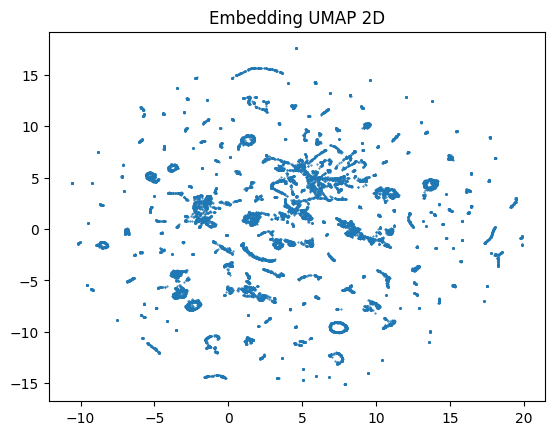

In [152]:
print(X_umap_2d.shape)

plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], marker=".", s=1)
plt.title("Embedding UMAP 2D")
plt.show()

## 2. Clustering

We are to apply several clustering algorithms and compare their performance.

### DBScan

Apply DBScan algorithm to the dataset and visualize the results.

See:
- https://en.wikipedia.org/wiki/DBSCAN
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

Print the number of clusters found by the algorithm and the number of samples in each cluster.

Try to find the best parameters for the algorithm.

Take note of the `-1` label in DBScan clustering results. Those are noise points that aren't dense enough to belong to any cluster. They are not a cluster - they're unclassified. Unlike K-Means, DBSCAN is honest-if a point doesn't belong anywhere, it doesn't force it into a cluster. High noise ratios often mean your eps is too small or your data is too sparse.



>  **Choosing `eps` is the hard part of DBSCAN.** The standard heuristic is the **k-distance plot**:
> 1. Set `k = min_samples` (a common rule of thumb: `min_samples ≈ 2 × n_features`, or just `2 × dim` if you've reduced).
> 2. For each point, compute the distance to its k-th nearest neighbor.
> 3. Sort those distances ascending and plot them.
> 4. The "knee" of the curve is a good `eps`.
>
> ```python
> from sklearn.neighbors import NearestNeighbors
> k = 2 * X_scaled.shape[1]
> dists, _ = NearestNeighbors(n_neighbors=k).fit(X_scaled).kneighbors(X_scaled)
> plt.plot(np.sort(dists[:, -1])); plt.ylabel(f"{k}-th NN distance"); plt.xlabel("points (sorted)")
> ```
**Note:** apply the "k rule" to the dimensionality of the embedding you actually cluster on, not the raw feature count. In practice, values in 5-20 are often sensible regardless.
>
> **Diagnostics to print:**
> ```python
> labels = dbscan.labels_
> n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
> n_noise = (labels == -1).sum()
> print(f"{n_clusters} clusters, {n_noise}/{len(labels)} noise ({n_noise/len(labels):.1%})")
> print(pd.Series(labels).value_counts().sort_index())
> ```
>
> If you get **1 cluster + lots of noise**: `eps` is too small. If you get **everything in one giant cluster**: `eps` is too large.

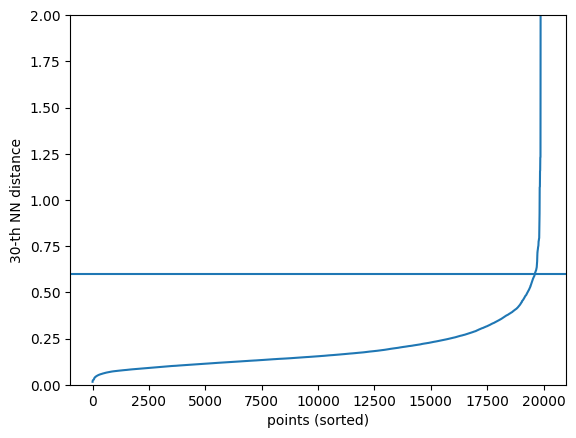

In [153]:
# write your code here
from sklearn.neighbors import NearestNeighbors

k = 2 * X_umap_cluster.shape[1]
dists, _ = NearestNeighbors(n_neighbors=k).fit(X_umap_cluster).kneighbors(X_umap_cluster)
plt.plot(np.sort(dists[:, -1]))
plt.ylabel(f"{k}-th NN distance")
plt.ylim(0, 2)
plt.axhline(y=0.6)
plt.xlabel("points (sorted)")
plt.show()


In [154]:
from sklearn.cluster import DBSCAN

eps = 0.6   # z wykresu
min_samples = k

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean', n_jobs=-1)

labels = dbscan.fit_predict(X_umap_cluster)
dbscan_labels = np.copy(labels)

In [155]:
import pandas as pd

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"{n_clusters} clusters, {n_noise}/{len(dbscan_labels)} noise ({n_noise/len(dbscan_labels):.1%})")
print(pd.Series(dbscan_labels).value_counts().sort_index())


43 clusters, 213/20000 noise (1.1%)
-1      213
 0     5086
 1       81
 2      246
 3     1326
 4      805
 5      344
 6     1279
 7     1297
 8      686
 9     1117
 10     549
 11     113
 12     168
 13     391
 14     358
 15    1771
 16     902
 17     210
 18     208
 19     105
 20     464
 21      42
 22     108
 23     342
 24     388
 25      44
 26      53
 27      80
 28     165
 29      41
 30     255
 31      49
 32      35
 33     161
 34      49
 35      98
 36      50
 37      52
 38      56
 39      39
 40      55
 41      38
 42      81
Name: count, dtype: int64


### Visualization in 2D, but using labels from DBSCAN clustering

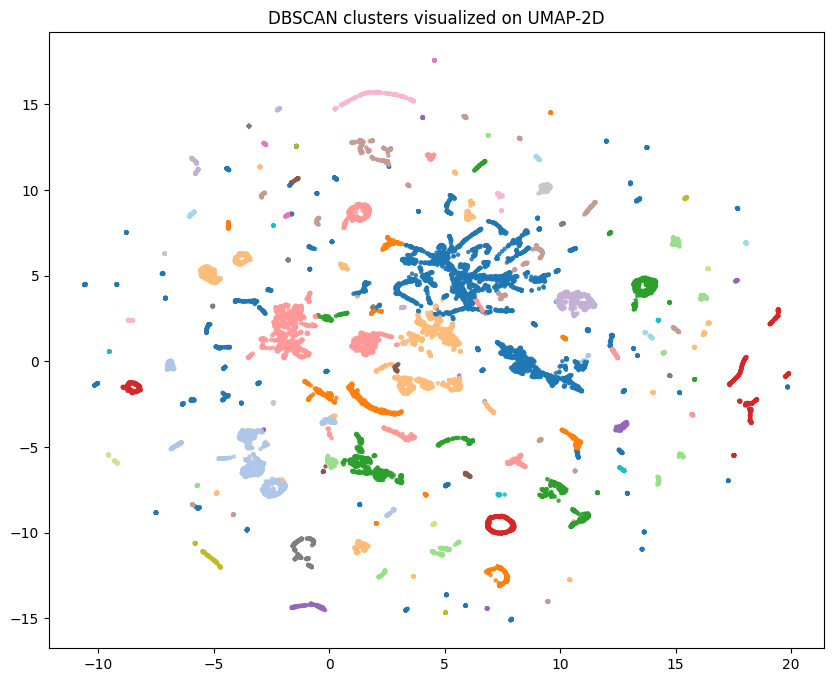

In [156]:
plt.figure(figsize=(10, 8))
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=labels, cmap='tab20', s=5, alpha=0.8)
plt.title("DBSCAN clusters visualized on UMAP-2D")
plt.show()


### Number of clusters and noise samples for different $\epsilon$ values

In [157]:
for eps in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4,  0.45, 0.6, 0.7, 0.8, 0.9, 1.0]:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_umap_cluster)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps}: {n_clusters} clusters, noise={n_noise}/{labels.size} ({n_noise/X_umap_cluster.shape[0]:.2%})")


eps=0.1: 129 clusters, noise=13041/20000 (65.20%)
eps=0.15: 154 clusters, noise=6218/20000 (31.09%)
eps=0.2: 132 clusters, noise=3422/20000 (17.11%)
eps=0.25: 113 clusters, noise=2077/20000 (10.38%)
eps=0.3: 98 clusters, noise=1185/20000 (5.92%)
eps=0.35: 80 clusters, noise=767/20000 (3.84%)
eps=0.4: 64 clusters, noise=531/20000 (2.66%)
eps=0.45: 57 clusters, noise=431/20000 (2.15%)
eps=0.6: 43 clusters, noise=213/20000 (1.06%)
eps=0.7: 40 clusters, noise=201/20000 (1.00%)
eps=0.8: 35 clusters, noise=159/20000 (0.80%)
eps=0.9: 33 clusters, noise=159/20000 (0.80%)
eps=1.0: 32 clusters, noise=159/20000 (0.80%)


The value of `eps = 0.6` seems a reasonable compromise between the number of clusters and the number of noise samples, which were not classified to any cluster.

### Curse of dimensionality

What is the curse of dimensionality? How does it affect the clustering algorithms?

- https://en.wikipedia.org/wiki/Curse_of_dimensionality#Distance_function
- https://medium.com/data-science/the-math-behind-the-curse-of-dimensionality-cf8780307d74


Try to reduce the dimensionality of the dataset prior to applying the clustering algorithm. You can use PCA or UMAP (it can be used not only for visualization, but also for dimensionality reduction) for this purpose. Are the results better? 

Try to experiment with different hyperparameters of PCA, UMAP and DBScan algorithms.


>  **Concrete intuition.** In high-dimensional Euclidean space, the ratio
> $$\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0 \quad \text{as} \quad \text{dim} \to \infty$$
> meaning that **all pairs of points become roughly equidistant**. "Near" and "far" stop being meaningful, density-based methods can't find dense regions, and `eps` either captures everything or nothing. This is the key reason DBSCAN often performs badly on raw high-D sensor data.
>
> See Aggarwal, Hinneburg & Keim (2001), *On the Surprising Behavior of Distance Metrics in High Dimensional Space*.
>
> **Two ways to push back:**
> - **PCA** — linear, fast, deterministic. Pick `n_components` to keep ~90–95% explained variance. Good when features are roughly linearly correlated.
> - **UMAP** — nonlinear, stochastic, preserves neighborhood structure. Use `n_components` in the 10–30 range as a clustering preprocessor. Slower but often captures structure PCA misses.
>


In [158]:
# write your code here

from sklearn.decomposition import PCA

var_exp = 0
n_comp = 10
while var_exp<0.92:
    n_comp += 50
    decomposer = PCA(n_components=n_comp).fit(X_scaled)
    var_exp = decomposer.explained_variance_ratio_.sum()
    print(f"N_components: {n_comp}, variance explained: {var_exp}")


N_components: 60, variance explained: 0.7323765472736535
N_components: 110, variance explained: 0.818826739180624
N_components: 160, variance explained: 0.8673204390377078
N_components: 210, variance explained: 0.898437305193112
N_components: 260, variance explained: 0.9212849601515753


Proper X dataset preprocessing with PCA method

In [159]:
pca = PCA(n_components=n_comp).fit(X_scaled)
X_pca = pca.transform(X_scaled)

print(X_pca.shape)

(20000, 260)


260


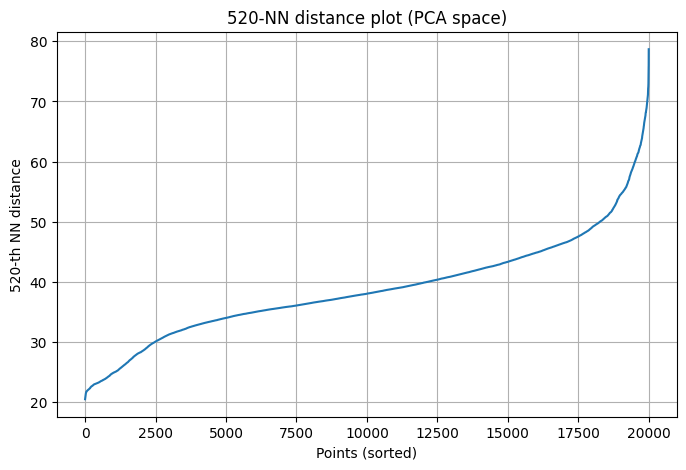

In [160]:
dim = X_pca.shape[1]
print(dim)
min_samples = 2 * dim

k = min_samples

nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
dists, _ = nbrs.kneighbors(X_pca)

k_dists = np.sort(dists[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dists)
plt.xlabel("Points (sorted)")
plt.ylabel(f"{k}-th NN distance")
plt.title(f"{k}-NN distance plot (PCA space)")
plt.grid(True)
plt.show()


In [161]:
for eps in [40, 45, 50, 55]:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_pca)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps}: {n_clusters} clusters, noise={n_noise}/{len(labels)}")


eps=40: 1 clusters, noise=2241/20000
eps=45: 1 clusters, noise=848/20000


KeyboardInterrupt: 

Those result means, that PCA does not work well here, so I will not continue using it and stay with UMAP preprocessing in 15 dimensions as a preprocessing for the main clustering process.

### Clustering evaluation

You can use different metrics to evaluate the clustering performance, e.g., Silhouette score - https://en.wikipedia.org/wiki/Silhouette_(clustering).
The meaning - silhouette ∈ [-1, 1]; near 1 = well-separated; near 0 = overlapping clusters; negative = sample probably assigned to wrong cluster.

Implement the Silhouette score function and compute the score for the clustering results. Verify if your implementation is correct by comparing the results with the `sklearn` implementation.

We can define Silhouette score $S$ using the following formulas:

- for a given sample $i$ in cluster $C_I$, we define the average distance (expressed in terms of a distance function $d$) to all other samples in the same cluster $C_I$. This can be interpreted as the measure of how well the sample $i$ fits into its own cluster. The situation when the sample is the only one in the cluster is a special case, handled separately later:

$$
a(i) = \frac{1}{|C_I| - 1} \sum_{j \in C_I, j \neq i} d(i, j)
$$

- for a given sample $i$ in cluster $C_I$, we define the average distance to all samples in the nearest cluster $C_J$. This can be interpreted as the measure of how well the sample $i$ fits into the nearest cluster. 

$$
b(i) = min_{J \neq I} \frac{1}{|C_J|} \sum_{j \in C_J} d(i, j)
$$

- we can define the silhouette score for a given sample $i$ as follows (we also handle the special case when the sample is the only one in the cluster):

$$
s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))} \textnormal{ if } (|C_I| > 1) \textnormal{ else } 0
$$

- we can define the silhouette score for the whole dataset as the average of the silhouette scores for all individual samples ($N$ is the number of samples in the dataset):

$$
S = \frac{1}{N}\sum_{i = 1}^N s(i)
$$

---
When implementing $b(i)$, remember it is the minimum average distance to any other cluster. Don't accidentally average the distances to all points outside the current cluster at once.

---

Implementation tips:

vectorize with sklearn.metrics.pairwise_distances to compute the full N×N (or chunked) distance matrix once.

handle the noise/outlier flag explicitly: filter by labels != -1 before computing the score, and report the fraction kept. You can also implement optional functionality (controlled by an appropriate flag argument) to ignore samples with the `-1` label (noise/outliers) in the silhouette score calculation. 

sanity-check by comparing against sklearn.metrics.silhouette_score on a small synthetic dataset (e.g., make_blobs(n_samples=300, centers=4)) - the values must match to ~1e-10 if the implementation is correct.



In [ ]:


from sklearn.metrics import pairwise_distances
from tqdm import tqdm


def silhouette_manual(X, labels, ignore_noise=True):
    if ignore_noise:
        mask = (labels != -1)
        X = X[mask]
        labels = labels[mask]

    unique_labels = np.unique(labels)
    N = X.shape[0]

    D = pairwise_distances(X)
    clusters = {lab: np.where(labels == lab)[0] for lab in unique_labels}

    s = np.zeros(N)

    for i in tqdm(range(N)):
        Ci = labels[i]
        idx_i = clusters[Ci]

        if idx_i.size == 1:
            s[i] = 0
            continue

        a_i = (D[i, idx_i].sum() - 0) / (idx_i.size - 1)

        b_i = np.inf
        for Cj in unique_labels:
            if Cj == Ci:
                continue
            idx_j = clusters[Cj]
            b_i = min(b_i, D[i, idx_j].mean())

        den = max(a_i, b_i)
        if den == 0:
            s[i] = 0
        else:
            s[i] = (b_i - a_i) / den

    return s.mean()



### Compute the Silhouette score

Compute the Silhouette score (with and without ignoring the samples with the `-1` label) for the clustering results obtained so far. Use the same distance function as the one used in the clustering algorithm.

In [163]:
# write your code here

from sklearn.metrics import silhouette_score

print("Silhouette score computed ignoring noise samples:")
print("manual:", silhouette_manual(X_scaled, dbscan_labels, ignore_noise=True))
print("sklearn:", silhouette_score(X_scaled[labels!=-1], dbscan_labels[labels!=-1]))

print("\nSilhouette score computed without ignoring noise samples:")
print("manual:", silhouette_manual(X_scaled, dbscan_labels, ignore_noise=False))
print("sklearn:", silhouette_score(X_scaled, dbscan_labels))


Silhouette score computed ignoring noise samples:


100%|██████████| 19787/19787 [00:15<00:00, 1292.37it/s]


manual: -0.0324064245521033
sklearn: -0.030802257026043254

Silhouette score computed without ignoring noise samples:


100%|██████████| 20000/20000 [00:12<00:00, 1664.11it/s]


manual: -0.033073000029007676
sklearn: -0.033073000029007676


### K-means algorithm

Run k-means clustering algorithm on the dataset. Visualize the results and compute the clustering quality metrics. Can you achieve good results without reducing the dimensionality of the dataset?

- https://en.wikipedia.org/wiki/K-means_clustering
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


> **K-means assumes:**
> 1. Clusters are **convex and roughly isotropic** (Voronoi cells are convex; k-means cannot recover ring-shaped, crescent, or elongated clusters).
> 2. Clusters have **similar variance**.
> 3. Clusters have **similar sizes** (k-means has a known bias toward balanced partitions because WCSS rewards splitting dense regions).
>
> Real sensor data (lots of rest, brief bursts of activity) likely violates all three. A typical failure mode on imbalanced activity data is **over-splitting the dominant "rest" state into several near-identical sub-clusters while small classes get absorbed into nearby larger ones**.
>
> See the visual demo: [Demonstration of k-means assumptions](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html).
>
> **Choosing `n_clusters`** — try two complementary methods:
> - **Elbow method**: plot `kmeans.inertia_` vs. `k` and look for the bend. Note that inertia is monotonically decreasing - there is no clear minimum; you're looking for the point of diminishing returns.
> - **Silhouette sweep**: plot silhouette vs. `k`; pick the local maximum.
>
> **Hint**: Set `n_init` explicitly. Pass `n_init=10` (or higher) explicitly if you can afford the computation.
>
> **Does it work on raw high-dim data?** Try it both ways: on the full feature space and on a PCA/UMAP-reduced version. The contrast is the whole point of the curse-of-dimensionality section above.

In [164]:
from sklearn.cluster import KMeans

K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)


for i, k in enumerate(K):
    print(f"k = {k}")
    km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(X_scaled)
    pred_labels = km.predict(X_scaled)
    inertias[i]=km.inertia_
    sil_scores[i] = silhouette_manual(X_scaled, pred_labels)
    print(sil_scores[i])

k = 10


100%|██████████| 20000/20000 [00:04<00:00, 4455.49it/s]


0.03284201713638792
k = 15


100%|██████████| 20000/20000 [00:05<00:00, 3592.51it/s]


0.03279972647844229
k = 20


...

0.03820249751367638
k = 55


100%|██████████| 20000/20000 [00:12<00:00, 1538.88it/s]


0.04107938004836183
k = 60


100%|██████████| 20000/20000 [00:13<00:00, 1436.82it/s]


0.04512339655988033


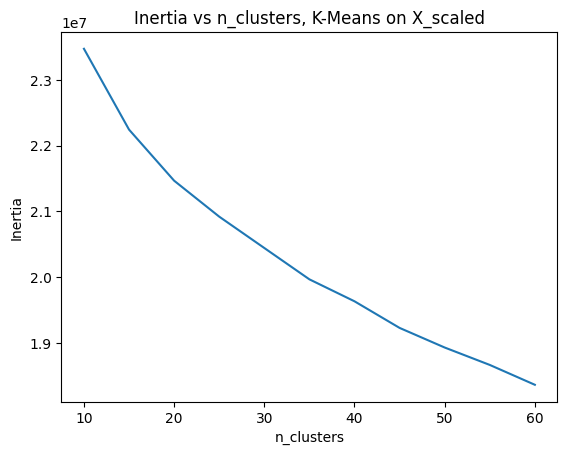

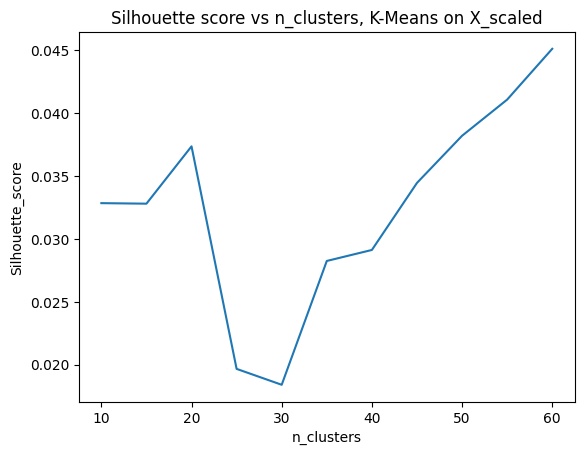

[0.03284202 0.03279973 0.03736115 0.01965562 0.01839062 0.02824261
 0.02911766 0.0344515  0.0382025  0.04107938 0.0451234 ]


In [165]:
def plot_clustering(K, inertias, sil_scores, method, dataset_name):
    plt.plot(K, inertias)
    plt.xlabel("n_clusters")
    plt.ylabel("Inertia")
    plt.title(f"Inertia vs n_clusters, {method} on {dataset_name}")
    plt.show()

    plt.plot(K, sil_scores)
    plt.xlabel("n_clusters")
    plt.title(f"Silhouette score vs n_clusters, {method} on {dataset_name}")
    plt.ylabel("Silhouette_score")
    plt.show()

plot_clustering(K, inertias, sil_scores, method="K-Means", dataset_name="X_scaled")

print(sil_scores)

In [166]:
K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)

for i, k in enumerate(K):
    print(f"k = {k}")
    km_umap = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_umap_cluster)
    pred_labels = km_umap.predict(X_umap_cluster)
    inertias[i]=km_umap.inertia_
    sil_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)
    print(sil_scores[i])

k = 10


100%|██████████| 20000/20000 [00:04<00:00, 4826.55it/s]


0.4799682866073097
k = 15


100%|██████████| 20000/20000 [00:05<00:00, 3731.41it/s]


0.5589359449483833
k = 20


...

0.5529726057169213
k = 55


100%|██████████| 20000/20000 [00:15<00:00, 1281.25it/s]


0.5688947611037191
k = 60


100%|██████████| 20000/20000 [00:17<00:00, 1150.59it/s]


0.562531470541004


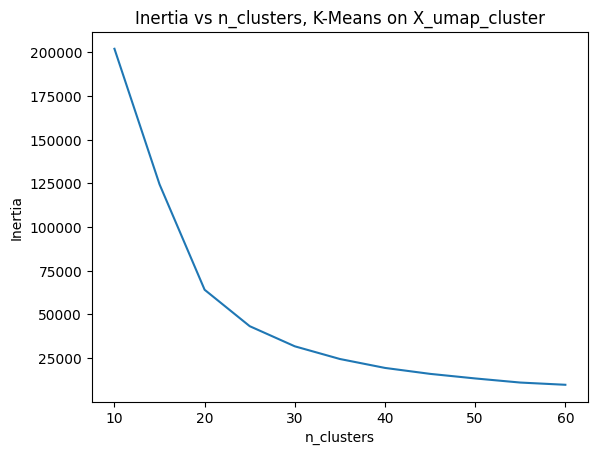

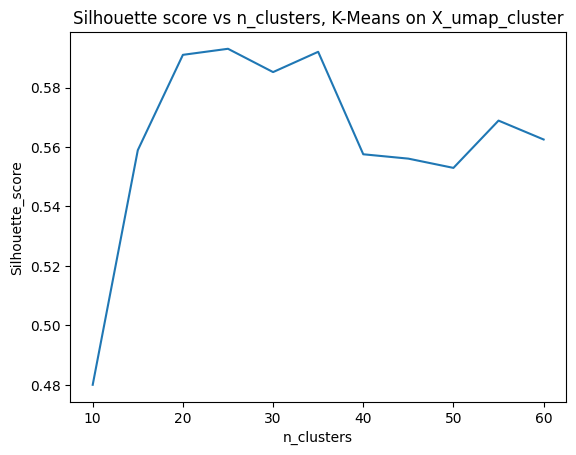

[0.47996829 0.55893594 0.5910258  0.59306678 0.58522047 0.59204819
 0.55755711 0.55609132 0.55297261 0.56889476 0.56253147]


In [167]:
plot_clustering(K, inertias, sil_scores, method="K-Means", dataset_name="X_umap_cluster")

print(sil_scores)

### K-medoids algorithm

Run k-medoids clustering algorithm on the dataset. Visualize the results and compute the clustering quality metrics. 

- https://en.wikipedia.org/wiki/K-medoids
- https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html

K-Medoids is more robust to outliers because it uses actual data points as centers (medoids) instead of the mean (centroids). Notice how this affects the clusters in the presence of sensor noise.


 **When to prefer k-medoids over k-means:**
 - You have outliers (sensor spikes, dropouts).
 - You need a non-Euclidean metric (Manhattan, cosine, precomputed dissimilarity).
 - You want cluster "exemplars" that are real observations - useful for inspection ("show me a typical sample from cluster 3").

### K-medoids on full X_scaled

In [168]:
# write your code here

from sklearn_extra.cluster import KMedoids

K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)

for i, k in enumerate(K):
    print(f"k = {k}")
    km = KMedoids(n_clusters=k, metric="euclidean", init="k-medoids++", random_state=42).fit(X_scaled)
    pred_labels = km.predict(X_scaled)
    inertias[i]=km.inertia_
    sil_scores[i] = silhouette_manual(X_scaled, pred_labels)
    print(sil_scores[i])


k = 10


100%|██████████| 20000/20000 [00:04<00:00, 4988.65it/s]


0.022027110150955424
k = 15


100%|██████████| 20000/20000 [00:04<00:00, 4091.70it/s]


0.018537970058238894
k = 20


...

0.021578645768648284
k = 55


100%|██████████| 20000/20000 [00:13<00:00, 1449.12it/s]


0.013073988439666825
k = 60


100%|██████████| 20000/20000 [00:14<00:00, 1384.97it/s]


0.016190451794397712


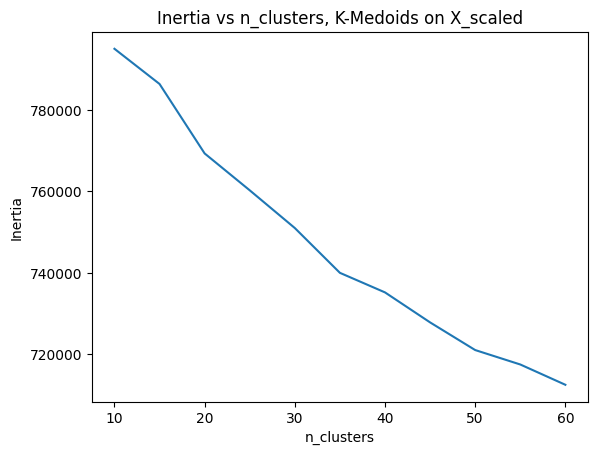

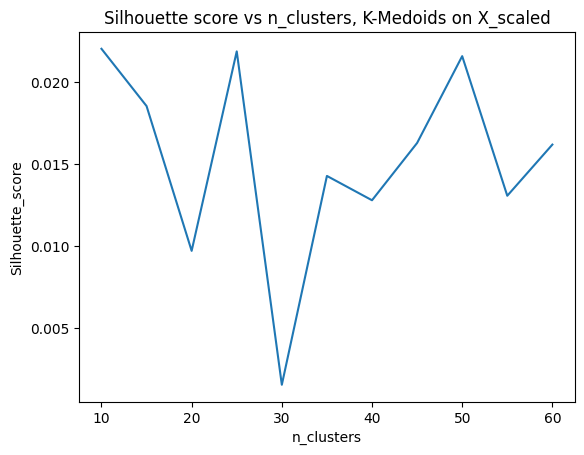

[0.02202711 0.01853797 0.00971731 0.0218697  0.00155877 0.01428184
 0.01279931 0.01628825 0.02157865 0.01307399 0.01619045]


In [169]:
plot_clustering(K, inertias, sil_scores, method="K-Medoids", dataset_name="X_scaled")

print(sil_scores)

The same using UMAP preprocessed dataset

In [170]:
K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)

for i, k in enumerate(K):
    print(f"k = {k}")
    km = KMedoids(n_clusters=k, metric="euclidean", init="k-medoids++", random_state=42).fit(X_umap_cluster)
    pred_labels = km.predict(X_umap_cluster)
    inertias[i]=km.inertia_
    sil_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)
    print(sil_scores[i])

k = 10


100%|██████████| 20000/20000 [00:04<00:00, 4593.40it/s]


0.47718850639230315
k = 15


100%|██████████| 20000/20000 [00:05<00:00, 3497.79it/s]


0.5397842058860045
k = 20


...

0.5604448959966817
k = 55


100%|██████████| 20000/20000 [00:16<00:00, 1246.59it/s]


0.5324659344191481
k = 60


100%|██████████| 20000/20000 [00:16<00:00, 1179.99it/s]


0.5464666327212948


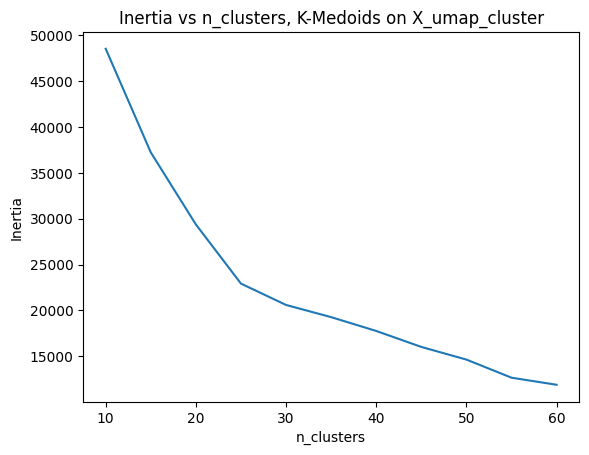

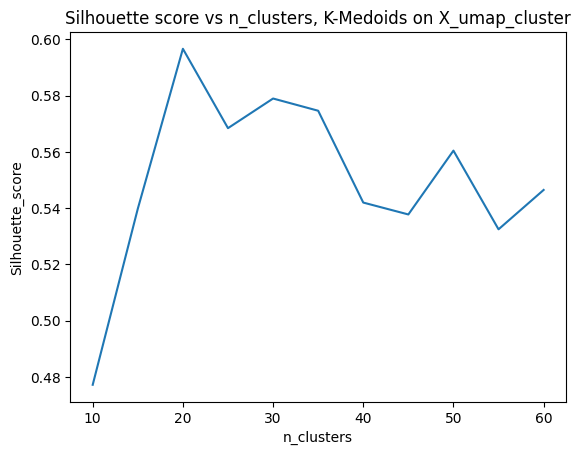

[0.47718851 0.53978421 0.59665749 0.56843417 0.57897169 0.57462926
 0.54197652 0.53774879 0.5604449  0.53246593 0.54646663]


In [171]:
plot_clustering(K, inertias, sil_scores, method="K-Medoids", dataset_name="X_umap_cluster")

print(sil_scores)

## CLARA algorithm

Compare the results of k-means and CLARA algorithms in terms of clustering quality metrics and computation time.

- https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.CLARA.html

>  **Why CLARA exists.** PAM (the proper k-medoids algorithm) is $O(k(n-k)^2)$ per iteration. On 50k samples, that's hours. **CLARA** = Clustering for Large Applications: run PAM on small random subsamples, keep the medoid set that minimizes total cost over the *full* dataset.
>
> The trade-off you should measure here is **speed vs. quality**:
> - K-medoids on the full sample: highest quality, slowest.
> - CLARA: lower quality, near-linear time.
> - K-means: fastest, but assumes round clusters.

In [172]:
# write your code here

from sklearn_extra.cluster import CLARA

K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)

for i, k in enumerate(K):
    print(f"k = {k}")
    clara = CLARA(n_clusters=k, metric="euclidean", random_state=42).fit(X_scaled)
    pred_labels = clara.predict(X_scaled)
    inertias[i]=clara.inertia_
    sil_scores[i] = silhouette_manual(X_scaled, pred_labels)
    print(sil_scores[i])


k = 10


100%|██████████| 20000/20000 [00:03<00:00, 5154.43it/s]


0.03323203712968798
k = 15


100%|██████████| 20000/20000 [00:04<00:00, 4143.95it/s]


0.042184759945317
k = 20


...

0.027780548409552148
k = 55


100%|██████████| 20000/20000 [00:12<00:00, 1643.03it/s]


0.03222845683087603
k = 60


100%|██████████| 20000/20000 [00:13<00:00, 1531.15it/s]

0.01959870114195831


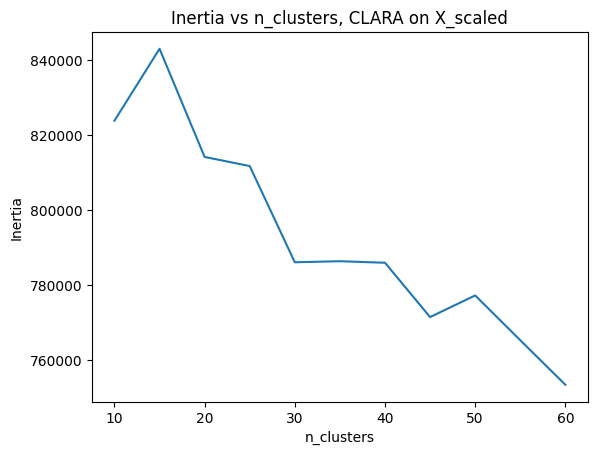

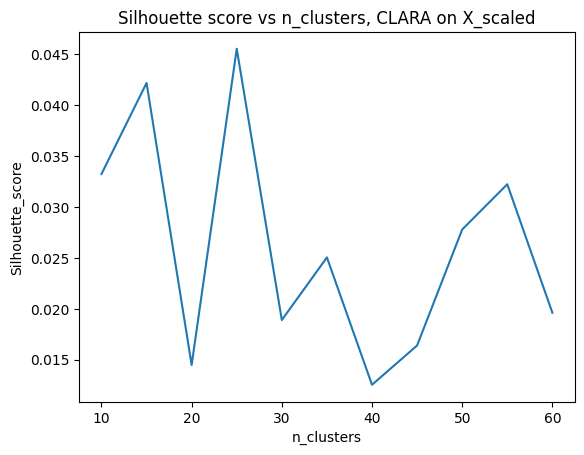

[0.03323204 0.04218476 0.01446774 0.04554267 0.01888603 0.02503626
 0.01252061 0.01638292 0.02778055 0.03222846 0.0195987 ]


In [173]:
plot_clustering(K, inertias, sil_scores, method="CLARA", dataset_name="X_scaled")

print(sil_scores)

In [174]:
# write your code here

from sklearn_extra.cluster import CLARA

K = np.arange(10, 61, 5)
sil_scores = np.zeros(len(K), dtype=float)
inertias = np.zeros(len(K), dtype=float)

for i, k in enumerate(K):
    print(f"k = {k}")
    clara = CLARA(n_clusters=k, metric="euclidean", random_state=42).fit(X_umap_cluster)
    pred_labels = clara.predict(X_umap_cluster)
    inertias[i]=clara.inertia_
    sil_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)
    print(sil_scores[i])


k = 10


100%|██████████| 20000/20000 [00:04<00:00, 4788.72it/s]


0.4482706522950707
k = 15


100%|██████████| 20000/20000 [00:05<00:00, 3699.90it/s]


0.4637217846407453
k = 20


...

0.4394897656046501
k = 55


100%|██████████| 20000/20000 [00:18<00:00, 1104.26it/s]


0.45817780361072763
k = 60


 37%|███▋      | 7344/20000 [00:06<00:11, 1141.19it/s]


KeyboardInterrupt: 

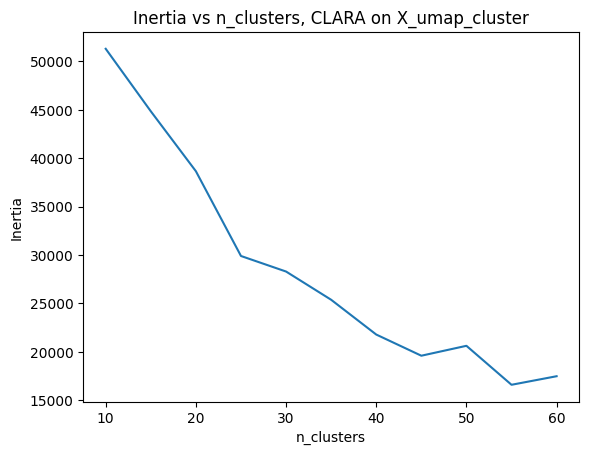

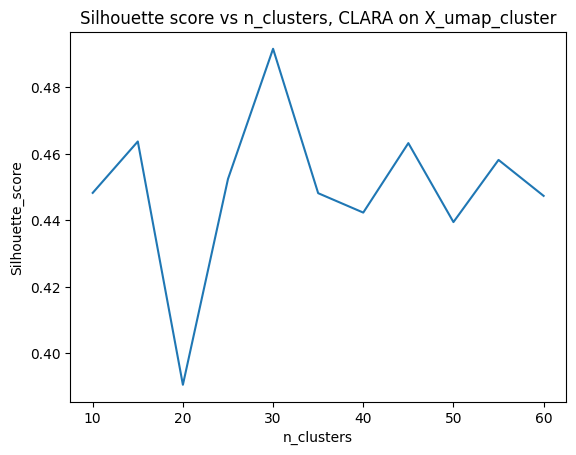

[0.44827065 0.46372178 0.39057836 0.45245076 0.49158846 0.44817711
 0.44234307 0.46323075 0.43948977 0.4581778  0.4473664 ]


In [ ]:
plot_clustering(K, inertias, sil_scores, method="CLARA", dataset_name="X_umap_cluster")

print(sil_scores)

### HDBSCAN algorithm

Run HDBSCAN clustering algorithm on the dataset. Visualize the results and compute the clustering quality metrics. 

- https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html
- https://en.wikipedia.org/wiki/Hierarchical_clustering

>  **HDBSCAN's big idea:** run DBSCAN at *all* values of `eps` simultaneously, build a hierarchy of clusters across density scales, then pick the clusters that are most *persistent* (stable across a wide range of `eps`). This removes DBSCAN's most painful hyperparameter and lets it find clusters of **varying density** - which DBSCAN can't.
>
> **Main parameter:** `min_cluster_size` - the smallest group you'd accept as a real cluster. Much more intuitive than `eps`. Try values like 10, 25, 50, 100 and see how the cluster count stabilizes.
>
>  **Two HDBSCAN implementations exist and they differ:**
> - `sklearn.cluster.HDBSCAN` (built-in since scikit-learn 1.3) - cleaner API, slower in practice.
> - `hdbscan.HDBSCAN` (the original library) -  faster, exposes the cluster hierarchy (condensed_tree_, single_linkage_tree_, minimum_spanning_tree_) and soft cluster membership.
>
> To match results between the two: sklearn's `min_samples` must be **1 higher** than the original library's. Pick one and document your choice.
>
> **Reading the output:** `-1` is noise, just like DBSCAN. `probabilities_` gives the strength of each point's cluster membership - useful for filtering "weak" assignments.

In [ ]:
# write your code here
from sklearn.cluster import HDBSCAN

cluster_sizes = np.array([5, 10, 25, 50, 75, 100])

for i, c_size in enumerate(cluster_sizes):
    hdb = HDBSCAN(min_cluster_size = c_size).fit(X_umap_cluster)
    labels = hdb.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"Minimal cluster size={c_size}: {n_clusters} clusters, noise={n_noise}/{len(labels)} ({(n_noise/labels.size):.2%})")
    print(f"Silhouette score with noise: {silhouette_manual(X_umap_cluster, labels, ignore_noise=False)}")
    print(f"Silhouette score excl. noise: {silhouette_manual(X_umap_cluster, labels, ignore_noise=True)}")



Minimal cluster size=5: 858 clusters, noise=3793/20000 (18.96%)


100%|██████████| 20000/20000 [04:04<00:00, 81.89it/s]


Silhouette score with noise: 0.3174676730823074


100%|██████████| 16207/16207 [03:10<00:00, 85.29it/s]


Silhouette score excl. noise: 0.6214487753610008
Minimal cluster size=10: 394 clusters, noise=2910/20000 (14.55%)


...

Silhouette score excl. noise: 0.691466014331946
Minimal cluster size=100: 24 clusters, noise=629/20000 (3.15%)


100%|██████████| 20000/20000 [00:09<00:00, 2215.83it/s]


Silhouette score with noise: 0.5775899535448545


100%|██████████| 19371/19371 [00:08<00:00, 2390.78it/s]


Silhouette score excl. noise: 0.6090297896890614


### Compare the results from different methods

Summarize the results of different clustering algorithms (on a plot or in a table) in terms of clustering quality metrics and computation time. Try to ensure that the results are comparable by using the same number of clusters (if possible) and the same dimensionality reduction method (if used before clustering).



> **Build a comparison table.** All rows must use **the same input** (same scaled features, same dimensionality reduction if any) and **the same random seed strategy** for the comparison to mean anything.
>
> For stochastic algorithms (K-Means, K-Medoids, CLARA, HDBSCAN with random tie-breaking), it is worth running **5 seeds** and reporting mean ± std for silhouette and wall time. Single-value comparisons are not robust.
>
> | algorithm | n_clusters | how `K` is set | noise % | silhouette (incl. noise) | silhouette (excl. noise) | wall_time (s) |
> |---|---|---|---|---|---|---|
> | DBSCAN | 43 | discovered | 1.06 | 0.3779 | 0.387 | 0.5756 |
> | HDBSCAN | 56 | discovered | 18.59 | 0.4215 | 0.6915 | 6.232 |
> | K-Means | 43 | specified | N/A | 0.5533 | N/A | 1.303 |
> | K-Medoids | 43 | specified | N/A | 0.5517 | N/A | 7.727 |
> | CLARA | 43 | specified | N/A | 0.4484 | N/A | 0.5196 |
>
> For fair comparison, set `K` for the parametric algorithms to whatever DBSCAN/HDBSCAN found (round to the nearest sensible value).
>
>  **Caveat on silhouette comparisons.** Silhouette rewards compact, convex, well-separated clusters — the shape K-Means tries to produce. K-Means and K-Medoids will therefore score *systematically higher* on silhouette than DBSCAN/HDBSCAN, even when the density-based clustering is arguably "better" for the underlying activities. A higher silhouette score does not automatically mean a better clustering. If you can, cross-check with **Davies-Bouldin** (lower is better) and **Calinski-Harabasz** (higher is better) — they have different biases.
>
> **Questions to answer:**
> 1. Where is the speed/quality Pareto frontier? Which algorithm wins, conditional on what?
> 2. Which algorithm produced the most balanced cluster sizes? Which most imbalanced?
> 3. Do the cluster shapes in the 2D UMAP plot match what each algorithm's assumptions would predict?
> 4. Looking at the actual *content* of the clusters (e.g. a few sample rows from each), do they correspond to recognizable activity patterns from the firefighter video?

### DBSCAN evaluation

In [176]:
import time

eps = 0.6 
start = time.time()
db = DBSCAN(eps=eps, min_samples=2*X_umap_cluster.shape[1], metric='euclidean', n_jobs=-1).fit(X_umap_cluster)
end = time.time()

execution_time = end-start

labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
K = n_clusters
print(K)
n_noise = (labels == -1).sum()
print(f"eps={eps}: {n_clusters} clusters, noise={n_noise}/{len(labels)} ({(n_noise/len(labels)):.2%})")

silhouette_score_all = silhouette_manual(X_umap_cluster, labels, ignore_noise=False)
silhouette_score_excl_noise = silhouette_manual(X_umap_cluster, labels, ignore_noise=True)

print(f"Execution time: {execution_time:.4} s")
print(f"Silhouette score with noise: {silhouette_score_all:.4}")
print(f"Silhouette score excl. noise: {silhouette_score_excl_noise:.4}")

43
eps=0.6: 43 clusters, noise=213/20000 (1.06%)


100%|██████████| 19787/19787 [00:14<00:00, 1401.42it/s]

Execution time: 0.5756 s
Silhouette score with noise: 0.3779
Silhouette score excl. noise: 0.387


### K-Means evaluation

In [187]:
random_seeds = np.array([1, 23, 42, 57, 82])
T = np.zeros(random_seeds.size)
Silhouette_scores = np.zeros(random_seeds.size)

print(f"Number of clusters: {K}")

for i, seed in enumerate(random_seeds):
    print(f"Seed: {seed}")
    start = time.time()
    km = KMeans(n_clusters=K, n_init=5, random_state=seed).fit(X_umap_cluster)
    end = time.time()
    T[i] = end-start
    pred_labels = km.predict(X_umap_cluster)
    Silhouette_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)

print(f"Avg execution time: {T.mean():.4}")
print(f"Std of execution time : {T.std():.4}")
print(f"Avg silhouette score: {Silhouette_scores.mean():.4}")
print(f"Std of silhouette score : {Silhouette_scores.std():.4}")


Number of clusters: 56
Seed: 1


100%|██████████| 20000/20000 [00:17<00:00, 1120.83it/s]


Seed: 23


100%|██████████| 20000/20000 [00:17<00:00, 1124.37it/s]


Seed: 42


...

Seed: 57


100%|██████████| 20000/20000 [00:17<00:00, 1112.90it/s]


Seed: 82


100%|██████████| 20000/20000 [00:17<00:00, 1115.71it/s]

Avg execution time: 1.303
Std of execution time : 0.07553
Avg silhouette score: 0.5533
Std of silhouette score : 0.01186


### K-Medoids evaluation

In [183]:
# write your code here

random_seeds = np.array([1, 23, 42, 57, 82])
T = np.zeros(random_seeds.size)
Silhouette_scores = np.zeros(random_seeds.size)

print(f"Number of clusters: {K}")

for i, seed in enumerate(random_seeds):
    print(f"Seed: {seed}")
    start = time.time()
    km = KMedoids(n_clusters=K, metric="euclidean", init="k-medoids++", random_state=seed).fit(X_umap_cluster)
    end = time.time()
    T[i] = end-start
    pred_labels = km.predict(X_umap_cluster)
    Silhouette_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)

print(f"Avg execution time: {T.mean():.4}")
print(f"Std of execution time : {T.std():.4}")
print(f"Avg silhouette score: {Silhouette_scores.mean():.4}")
print(f"Std of silhouette score : {Silhouette_scores.std():.4}")



Number of clusters: 56
Seed: 1


100%|██████████| 20000/20000 [00:18<00:00, 1110.80it/s]


Seed: 23


100%|██████████| 20000/20000 [00:17<00:00, 1115.64it/s]


Seed: 42


...

Seed: 57


100%|██████████| 20000/20000 [00:17<00:00, 1125.66it/s]


Seed: 82


100%|██████████| 20000/20000 [00:18<00:00, 1063.64it/s]


Avg execution time: 7.727
Std of execution time : 0.3163
Avg silhouette score: 0.5517
Std of silhouette score : 0.01209


### CLARA evaluation

In [184]:
# write your code here

random_seeds = np.array([1, 23, 42, 57, 82])
T = np.zeros(random_seeds.size)
Silhouette_scores = np.zeros(random_seeds.size)

print(f"Number of clusters: {K}")

for i, seed in enumerate(random_seeds):
    print(f"Seed: {seed}")
    start = time.time()
    clara = CLARA(n_clusters=K, metric="euclidean", random_state=seed).fit(X_umap_cluster)
    end = time.time()
    T[i] = end-start
    pred_labels = clara.predict(X_umap_cluster)
    Silhouette_scores[i] = silhouette_manual(X_umap_cluster, pred_labels)

print(f"Avg execution time: {T.mean():.4}")
print(f"Std of execution time : {T.std():.4}")
print(f"Avg silhouette score: {Silhouette_scores.mean():.4}")
print(f"Std of silhouette score : {Silhouette_scores.std():.4}")



Number of clusters: 56
Seed: 1


100%|██████████| 20000/20000 [00:18<00:00, 1109.65it/s]


Seed: 23


100%|██████████| 20000/20000 [00:17<00:00, 1115.60it/s]


Seed: 42


...

Seed: 57


100%|██████████| 20000/20000 [00:17<00:00, 1123.31it/s]


Seed: 82


100%|██████████| 20000/20000 [00:17<00:00, 1113.05it/s]


Avg execution time: 0.5196
Std of execution time : 0.03256
Avg silhouette score: 0.4484
Std of silhouette score : 0.02575


In [185]:
import time

start = time.time()
db = HDBSCAN(min_cluster_size=75, n_jobs=-1).fit(X_umap_cluster)
end = time.time()

execution_time = end-start

labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
K = n_clusters
n_noise = (labels == -1).sum()
print(f"eps={eps}: {n_clusters} clusters, noise={n_noise}/{len(labels)} ({(n_noise/len(labels)):.2%})")

silhouette_score_all = silhouette_manual(X_umap_cluster, db.labels_, ignore_noise=False)
silhouette_score_excl_noise = silhouette_manual(X_umap_cluster, db.labels_, ignore_noise=True)

print(f"Execution time: {execution_time:.4} s")
print(f"Silhouette score with noise: {silhouette_score_all:.4}")
print(f"Silhouette score excl. noise: {silhouette_score_excl_noise:.4}")

eps=0.6: 56 clusters, noise=3719/20000 (18.59%)


100%|██████████| 16281/16281 [00:14<00:00, 1148.68it/s]


Execution time: 6.232 s
Silhouette score with noise: 0.4215
Silhouette score excl. noise: 0.6915


## (*) 3. Use clustering algorithms to select the initial batch

Use some of the above clustering algorithms to extend the analysis of initial batch selection exercise from the previous lab.


In [186]:
# write your code here





Key takeaways

**No free lunch in clustering.** K-means is fast and well-understood but assumes round, equally-sized clusters in Euclidean space. DBSCAN finds arbitrary shapes but is allergic to high dimensions and needs careful eps tuning. HDBSCAN removes the eps headache and handles varying density, at the cost of speed. K-medoids/CLARA buy you robustness to outliers and any distance metric, at the cost of computational complexity. The "best" algorithm is the one whose assumptions match your data.

**Scaling and dimensionality reduction are not optional.** Almost every disappointing clustering result on real sensor data traces back to missing one of these steps. Standardize first; then if d > ~15, reduce dimensionality before clustering, not just for visualization.

**Don't cluster on the 2D visualization embedding.** Visualization UMAP (n_components=2) optimizes for human eyes; clustering UMAP/PCA (n_components=10-30) preserves more structure. Use different embeddings for the two purposes.

**Silhouette score is a tool, not an oracle.** It rewards compact, well-separated clusters - which biases it toward k-means-shaped solutions. A low silhouette doesn't always mean bad clustering (e.g., DBSCAN finding genuine long, thin clusters). Cross-check with at least one other metric (Davies-Bouldin, Calinski-Harabasz) and, when possible, with a domain-expert sanity check. The art of unsupervised learning lies in the validation.

**Match the distance metric end-to-end.** If you cluster with Manhattan distance, evaluate with Manhattan distance. Mismatches silently corrupt your conclusions.